In [1]:
# Load the images
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import gaussian_kde
import plotly.graph_objects as go

png_images_path = 'data/thermal_ironbow/'

def load_images(folder):
    """Load images from a given folder and return as a list of numpy arrays."""
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img = cv2.imread(os.path.join(folder, filename))
            if img is not None:
                # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
    return images


def compute_color_relative_intensity(image, color='red'):
    """Compute the Red Relative Intensity (RRI) of an image."""
    r, g, b = cv2.split(image)
    total_intensity = (r + g + b).astype(np.float32) + 1e-6  # Avoid division by zero
    if color == 'red':
        r_relative = r.astype(np.float32) / total_intensity
    elif color == 'green':
        r_relative = g.astype(np.float32) / total_intensity
    elif color == 'blue':
        r_relative = b.astype(np.float32) / total_intensity
    else:
        raise ValueError("Color must be 'red', 'green', or 'blue'")

    return np.mean(r_relative)


def perform_ks_test(baseline_mrri, test_mrri):
    """Perform the Kolmogorov-Smirnov test to detect significant change."""
    ks_stat, p_value = stats.ks_2samp(baseline_mrri, test_mrri)
    return ks_stat, p_value


def remove_safe_red(img, threshold_red=0):
    r, g, b = cv2.split(img)
    mask = r < threshold_red
    r[mask] = 0 
    return cv2.merge((r, g, b))


def compute_gaussian_kde(data):
    kde = gaussian_kde(data)
    x_range = np.linspace(min(data), max(data), 1000)
    pdf_values = kde(x_range)
    return pdf_values, x_range


def plot_mrri_over_time(mrri_values, ref_start, ref_end, test_start, test_end):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=list(range(len(mrri_values))),y=mrri_values, name='MRRI', mode='lines+markers', marker=dict(size=4), line=dict(width=1)))
    fig.add_vrect(x0=ref_start, x1=ref_end, fillcolor="lightblue", opacity=0.5, layer="below", line_width=0, name="Reference Range")
    fig.add_vrect(x0=test_start, x1=test_end, fillcolor="tomato", opacity=0.5, layer="below", line_width=0, name="Test Range")
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightblue', opacity=0.5), name='Reference Range', showlegend=True))
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='tomato', opacity=0.5), name='Test Range',showlegend=True))

    fig.update_layout(
        hovermode='x unified',
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
        margin=dict(l=50, r=50, b=50, t=50, pad=0)
    )

    fig.show()

In [2]:
images = load_images(png_images_path)
images = [remove_safe_red(img, 0) for img in images]
print(f"Loaded {len(images)} images.")

ref_start = 321
ref_end = 389
test_start = 380
test_end = 389

ref_images = images[ref_start:ref_end]
test_images = images[test_start:test_end]
mrri_values = [compute_color_relative_intensity(img, 'red') for img in images]
ref_mrri_values = [compute_color_relative_intensity(img, 'red') for img in ref_images]
test_mrri_values = [compute_color_relative_intensity(img, 'red') for img in test_images]

# Perform KS test
ks_stat, p_value = perform_ks_test(ref_mrri_values, test_mrri_values)
print(f"KS Statistic: {ks_stat}, P-Value: {p_value}")

plot_mrri_over_time(mrri_values, ref_start, ref_end, test_start, test_end)

Loaded 389 images.
KS Statistic: 0.47058823529411764, P-Value: 0.038695565302925845


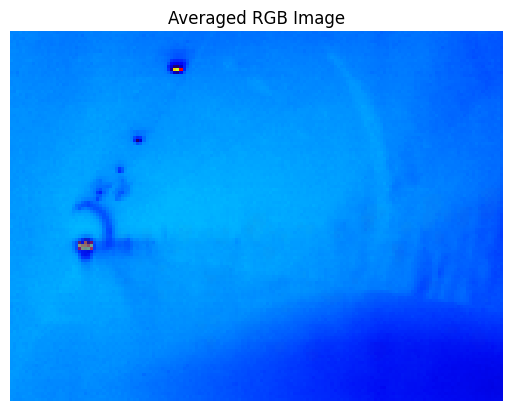

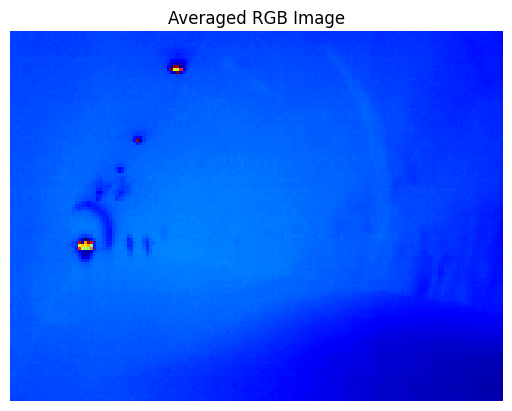

In [3]:
img_stack = np.stack(ref_images, axis=0)  # Stack images along a new dimension
avg_img = np.mean(img_stack, axis=0).astype(np.uint8)  # Compute mean and convert to uint8

# Plot the averaged image
plt.imshow(avg_img)
plt.axis('off')
plt.title("Averaged RGB Image")
plt.show()

img_stack = np.stack(test_images, axis=0)  # Stack images along a new dimension
avg_img = np.mean(img_stack, axis=0).astype(np.uint8)  # Compute mean and convert to uint8

# Plot the averaged image
plt.imshow(avg_img)
plt.axis('off')
plt.title("Averaged RGB Image")
plt.show()

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def display_animation(images, interval=100):
    """
    Display images as animation using matplotlib.
    
    Args:
        images: List of numpy array images
        interval: Delay between frames in milliseconds
    """
    fig = plt.figure(figsize=(10, 6))
    plt.axis('off')
    
    ims = [[plt.imshow(img, animated=True)] for img in images]
    ani = animation.ArtistAnimation(
        fig, ims, interval=interval, blit=True, repeat_delay=1000
    )
    
    plt.close()
    return HTML(ani.to_jshtml())

# Display the animation
display_animation(images, interval=100)